In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from dl_model.trainer_lstm import train_lstm
from outils.gridsearch import grid_search

2026-04-21 11:33:46.968104: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 11:33:47.009670: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 11:33:47.010766: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-21 11:33:48.423233: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Train: (699, 120)
Validation: (150, 120)
Test : (150, 120)
GridSearch lancé sur 4 combinaisons
Parallelisation avec n_jobs=-1


2026-04-21 11:33:54.083966: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 11:33:54.115155: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 11:33:54.122381: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 11:33:54.129228: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 11:33:54.129676: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-21 11:33:54.160124: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 120, 64)           47360     
                                                                 
 dropout (Dropout)           (None, 120, 64)           0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 59809 (233.63 KB)
Trainable params: 59809 (233.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "sequential

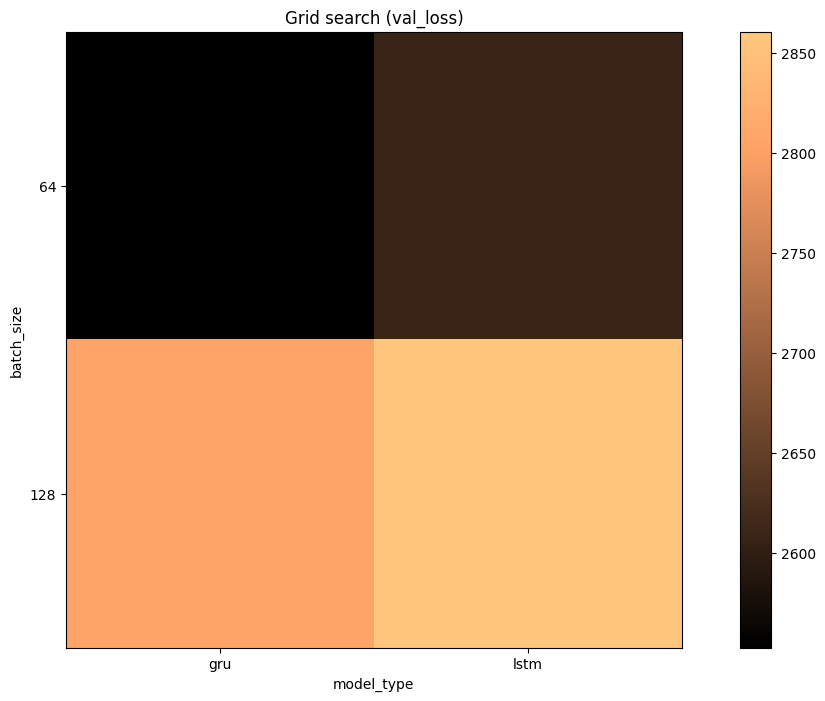

  model_type  batch_size  epochs  verbose     val_loss    val_mae
0       lstm          64      20        0  2609.518555  51.083408
1       lstm         128      20        0  2860.527588  53.483868
2        gru          64      20        0  2552.862061  50.525818
3        gru         128      20        0  2805.425049  52.966232


In [2]:
# Chargement du jeu de données
df = pd.read_csv("WADI_clean.csv")

target = "3_LT_001_PV" # pour l'instant on ne le fait que sur une cible


# features = tout sauf la target
X = df.drop(columns=[target])
y = df[target]

# Suppression des colonnes non numériques
X = X.select_dtypes(include=[np.number])

# Split
# /!\ : pas de shuffle pour séries temporelles

split_1 = int(len(df) * 0.7)
split_2 = int(len(df) * 0.85)

X_train = X.iloc[:split_1]
y_train = y.iloc[:split_1]

X_val = X.iloc[split_1:split_2]
y_val = y.iloc[split_1:split_2]

X_test  = X.iloc[split_2:]
y_test  = y.iloc[split_2:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test :", X_test.shape)

# Gridsearch
p_grid = {
    "model_type": ["lstm", "gru"],
    "batch_size": [64, 128],# premier test
    "epochs": [20],
    "verbose": [0] # pour empêcher de tout voir
}

df_results = grid_search(
    trainer=train_lstm,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    p_grid=p_grid,
    score_opt="val_loss"
)

print(df_results)

In [3]:
best = df_results.loc[df_results["val_loss"].idxmin()]

In [4]:
model, scaler, history = train_lstm(
    X_train, y_train,
    X_val, y_val,
    model_type=best["model_type"],
    batch_size=int(best["batch_size"]),
    epochs=int(best["epochs"])
)

Epoch 1/20
10/10 [==============================] - 4s 121ms/step - loss: 3993.7136 - mae: 63.1876 - val_loss: 3781.1091 - val_mae: 61.4907 - lr: 0.0010
Epoch 2/20
10/10 [==============================] - 1s 60ms/step - loss: 3650.9675 - mae: 60.4174 - val_loss: 3502.7522 - val_mae: 59.1840 - lr: 0.0010
Epoch 3/20
10/10 [==============================] - 1s 58ms/step - loss: 3439.8191 - mae: 58.6460 - val_loss: 3374.3916 - val_mae: 58.0895 - lr: 0.0010
Epoch 4/20
10/10 [==============================] - 1s 58ms/step - loss: 3349.6423 - mae: 57.8713 - val_loss: 3310.5239 - val_mae: 57.5371 - lr: 0.0010
Epoch 5/20
10/10 [==============================] - 1s 59ms/step - loss: 3290.7087 - mae: 57.3601 - val_loss: 3261.2417 - val_mae: 57.1072 - lr: 0.0010
Epoch 6/20
10/10 [==============================] - 1s 58ms/step - loss: 3239.8657 - mae: 56.9149 - val_loss: 3216.0891 - val_mae: 56.7105 - lr: 0.0010
Epoch 7/20
10/10 [==============================] - 1s 60ms/step - loss: 3196.0815 - ma

In [9]:
from dl_model.sequences_lstm import prepare_sequences

In [10]:
X_test_seq, y_test_seq = prepare_sequences(scaler.transform(X_test), y_test.values)

X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], X_test_seq.shape[1], X_test_seq.shape[2]))

model.evaluate(X_test_seq, y_test_seq)

1/1 [==============================] - 0s 36ms/step - loss: 2686.4636 - mae: 51.8311


[2686.463623046875, 51.83106231689453]

In [11]:
# Prédiction

In [17]:
from dl_model.forecast_lstm import forecast_lstm_direct
from dl_model.config_lstm import WINDOW_SIZE

In [18]:
preds = forecast_lstm_direct(model=model,
    val=X_test,        # ou une partie récente du dataset
    scaler=scaler,
    saisonalite=WINDOW_SIZE)

/u2/users/cycle3/sipahimalani/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ValueError: X has 1 features, but MinMaxScaler is expecting 120 features as input.